# Email Spam Detector — Data Exploration

## Project Objective

The goal of this project is to build a machine learning system that classifies messages as either spam or legitimate (ham).

This notebook focuses on understanding and preparing the dataset before model development.

## Workflow

1. Load the dataset
2. Inspect the data
3. Understand the target labels
4. Check for missing values and duplicates
5. Explore the class distribution
6. Analyze message characteristics
7. Prepare the data for machine learning

In [2]:
import pandas as pd

In [3]:
file_path = "../data/SMSSpamCollection"

df = pd.read_csv(
    file_path,
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.shape

(5572, 2)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [7]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [8]:
label_counts = df["label"].value_counts()

label_percentages = df["label"].value_counts(normalize=True) * 100

label_percentages

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

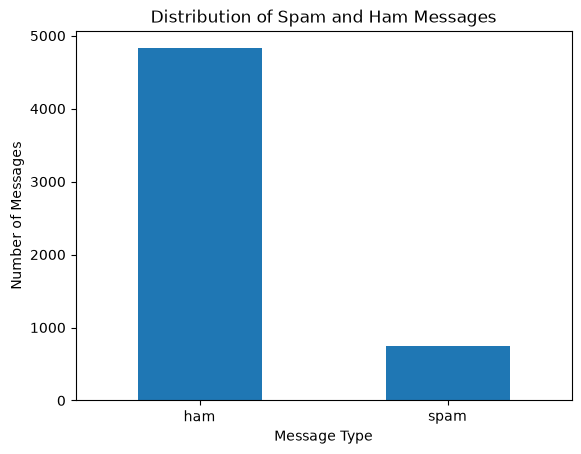

In [9]:
import matplotlib.pyplot as plt

label_counts = df["label"].value_counts()

label_counts.plot(kind="bar")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)

plt.show()

In [10]:
df.isnull().sum()


label      0
message    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(403)

In [12]:
duplicates = df[df.duplicated(keep=False)]

duplicates.head(10)

,label,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."
12,spam,URGENT! You have won a 1 week FREE membership ...
45,ham,No calls..messages..missed calls
62,ham,Its a part of checking IQ
65,spam,"As a valued customer, I am pleased to advise y..."
66,ham,"Today is ""song dedicated day.."" Which song wil..."


In [13]:
duplicate_label_counts = (
    duplicates.groupby("message")["label"]
    .nunique()
)

duplicate_label_counts.value_counts()

label
1    281
Name: count, dtype: int64

In [14]:
df_clean = df.drop_duplicates().copy()

In [15]:
df_clean.shape

(5169, 2)

In [16]:
df_clean.duplicated().sum()

np.int64(0)

In [17]:
df_clean["message_length"] = df_clean["message"].str.len()

In [18]:
df_clean[["label", "message", "message_length"]].head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [19]:
df_clean["message_length"].describe()

count    5169.000000
mean       79.344554
std        58.437457
min         2.000000
25%        36.000000
50%        61.000000
75%       119.000000
max       910.000000
Name: message_length, dtype: float64